# Resource estimation for simulating a 2D Hubbard model

In this Python + Q# notebook we demonstrate how to *efficiently* estimate the resources required to simulate a Hubbard model Hamiltonian on an $N \times N$ 2D
lattice using a *fourth-order Trotter Suzuki product formula* assuming a 2D planar qubit architecture with nearest-neighbor connectivity.

First, load the necessary packages.

In [37]:
from qdk import qsharp
import pandas as pd

## Background: 2D Hubbard Model

The Hubbard Model is a simple model of interacting particles in a lattice (in our case a 2D square lattice) with two kinds of terms in the Hamiltonian: (i) a hopping term between adjacent sites and (ii) a potential term for onsite interactions.
Formally, a Hubbard model Hamiltonian on an $N \times N$ lattice where each site has two spins {up, dn} is given as:

$$
H = \underbrace{U \sum_{i,j} c^{\dagger}_{(i, j), \text{up}} c_{(i, j), \text{up}}  c^{\dagger}_{(i, j), \text{dn}} c_{(i, j), \text{dn}}}_{B} - \underbrace{t \sum_{\sigma \in \{ \text{up}, \text{dn}\} , i, j} ( c^\dagger_{(i,j),\sigma} c_{(i+1,j),\sigma} + c^\dagger_{(i+1,j),\sigma} c_{(i,j),\sigma})}_{A} - \underbrace{t \sum_{\sigma \in \{ \text{up}, \text{dn}\} , i, j} ( c^\dagger_{(i,j),\sigma} c_{(i,j+1),\sigma} + c^\dagger_{(i,j+1),\sigma} c_{(i,j),\sigma})}_{C}
$$
where $c$ is the annihilation operator, $c^\dagger$ is the creation operator, the first set of terms are the on-site repulsion terms, the second set are the vertical row hops and last set is the horizontal column hops.

### Converting to Pauli terms

The first step needed to simulate $H$ is to map the fermionic terms into *local* Pauli operations involving only a few qubits. When the Hamiltoinan acts on a 1D lattice, using the Jordan-Wigner would suffice. However, for the 2D lattice, either row or column hops will end up being non-local terms involving $O(N)$ qubits.
To overcome this, we use the [Verstraete-Cirac](http://arxiv.org/abs/cond-mat/0508353v3) encoding to convert the repulsion and hopping terms into local Pauli operators involving at most 4 qubits at a time. This is done by adding one auxiliary qubit for each spin type in each lattice site such that the $N^2$ lattice sites are mapped to $4 N^2$ qubits. Specifically, each lattice site $m$ maps to the qubits $\{u_m, d_m, \tilde{u}_m \tilde{d}_m\}$ where the first two qubits correspond to the up and down spin types and the latter two to the corresponding auxiliary qubits.

This converts the terms as follows:
$$
\text{Repulsion Terms:} \qquad   c^{\dagger}_{(i, j), \text{up}} c_{(i, j), \text{up}}  c^{\dagger}_{(i, j), \text{dn}} c_{(i, j), \text{dn}} \mapsto \frac{1}{4} \left(\mathbb{I} - Z_{(i,j), \text{up}} - Z_{(i,j), \text{dn}} + Z_{(i,j), \text{up}} \otimes Z_{(i,j), \text{dn}}\right)
$$
$$
\text{Horizontal Hopping Terms:} \qquad c^\dagger_{(i,j),\sigma} c_{(i,j+1),\sigma} + c^\dagger_{(i,j+1),\sigma} c_{(i,j),\sigma} \mapsto \frac{1}{2} \left(X_{(i,j),\sigma} X_{(i,j+1),\sigma} + Y_{(i,j),\sigma} Y_{(i,j+1),\sigma} \right) \tilde{Z}_{(i,j),\sigma}
$$
$$
\text{Vertical Hopping Terms:} \qquad c^\dagger_{(i,j),\sigma} c_{(i+1,j),\sigma} + c^\dagger_{(i+1,j),\sigma} c_{(i,j),\sigma} \mapsto \frac{(-1)^{i+1}}{2}  \begin{cases} \left(X_{(i,j),\sigma} Y_{(i+1,j), \sigma} - Y_{(i,j),\sigma} X_{(i+1,j),\sigma} \right) \tilde{X}_{(i,j),\sigma} \tilde{Y}_{(i+1,j), \sigma} & (j \text{ is even}); \\
\left(X_{(i,j),\sigma} Y_{(i+1,j), \sigma} -  Y_{(i,j),\sigma} X_{(i+1,j),\sigma} \right) \tilde{Y}_{(i,j),\sigma} \tilde{X}_{(i+1,j), \sigma}  & (j \text{ is odd}). \end{cases}
$$
where the $\tilde{(\cdot)}$ terms are Paulis acting on the auxiliary system.

### Simulation

Now that the Hamiltonian has been converted into $H = \sum_k h_k$ where each $h_k$ is a Local Hamiltonian term, we can consider how to implement $e^{-iHT}$ using the fourth order Trotter-Suzuki product formula. For this, we simulate the evolution for small slices of time $\Delta$ and repeating this for `nSteps` $= \lceil T/\Delta \rceil$ to obtain the full time evolution. The Trotter-Suzuki formula for higher orders can be recursively defined using a *fractal decomposition* as discussed in Section 3 of [Hatanao and Suziki's survey](https://link.springer.com/chapter/10.1007/11526216_2). Then the fourth order formula $U_4(\Delta)$ can be constructed using the second-order one $U_2(\Delta)$ as follows.
$$
\begin{aligned}
U_2(\Delta) & = e^{-iA\Delta/2} e^{-iB\Delta/2} e^{-iC\Delta} e^{-iB\Delta/2} e^{-iA\Delta/2}; \\
U_4(\Delta) & = U_2(p\Delta)U_2(p\Delta)U_2((1 - 4p)\Delta)U_2(p\Delta)U_2(p\Delta); \\
p & = (4 - 4^{1/3})^{-1}.
\end{aligned}
$$

For the rest of the notebook, we will present the code that computes the time evolution in a step by step fashion.

## Implementation

### Helper functions

We will allocate all qubits in the 2D lattice in a one-dimensional array where every lattice point has 4 qubits ordered as $(u, u', d, d')$. Further we assume a snake-like order on the 2D lattice i.e., the ordering goes left-to-right on even rows and right-to-left on odd rows. The function `GetQubitIndex` converts a qubit identified by its 2D lattice point coordinates, `(row, col)`, its spin flag `f_spin` and auxiliary flag `f_aux` to an index in the qubit array. Note that `f_spin = True` for the down spin and `f_aux = True` for auxiliary qubits.

In [38]:
%%qsharp
function GetQubitIndex(k : Int, l : Int, f_spin : Bool, f_aux : Bool, n : Int, m : Int) : Int {

    let sshift = f_spin ? 2 | 0;
    let ashift = f_aux ? 1 | 0;

    return k % 2 == 0    //Check if row is even and return expression accordingly
        ? 4*m*k + 4*l + ashift + sshift
        | 4*m*k + 4*(m-l-1) + (ashift) + (sshift);
}

Expanding $U_4(\Delta)$ to express it in terms of $A, B, C$ gives:
$$
\begin{aligned}
U_4(\Delta) & = e^{-iAp\Delta/2} \ T_1 \ T_2 \ T_1 \ e^{-iAp\Delta/2}, \\
\text{where } T_1 & = e^{-iBp\Delta/2} e^{-iCp\Delta} e^{-iBp\Delta/2} e^{-iAp\Delta} e^{-iBp\Delta/2} e^{-iCp\Delta} e^{-iBp\Delta/2}, \\
\text{and } T_2 & = e^{-iA(1 - 3p)\Delta/2} e^{-iB(1-4p)\Delta/2} e^{-iC(1-4p)\Delta} e^{-iB(1-4p)\Delta/2} e^{-iA(1 - 3p)\Delta/2}.
\end{aligned}
$$

The above equation has $21$ exponential terms and works for one time step. For `nSteps` $> 1$ time steps, some adjacent terms can be merged to give $20\lceil T/\Delta \rceil+1$ exponential terms for time evolution $e^{-iHT}$.

The function below sets the rotation angles used to apply the exponentials involving $A, B$ and $C$ in the formula above.

In [39]:
%%qsharp
function SetAngleSequence(p : Double, hop_angle : Double, rep_angle : Double, dt : Double) : Double[] {
    let len1 = 8;
    let len2 = 4;
    let valLength = 2*len1 + len2;

    let val1 = -p*hop_angle*dt;
    let val2 = -p*rep_angle*dt/2.0;

    let valB = -(1.0-4.0*p)*rep_angle*dt/2.0;
    let valA = -(1.0-3.0*p)*hop_angle*dt/2.0;
    let valC = -(1.0-4.0*p)*hop_angle*dt;

    mutable values = [0.0, size=valLength];

    // Angles bookending Term2
    set values w/= len1 <- valA;
    set values w/= len1+len2 <- valA;

    for i in 0..len1-1 {
        if (i%2 == 0) {
            set values w/= i <- val1;
        }
        else {
            set values w/= i <- val2;
        }
    }

    for i in len1+1..len1+len2-1 {
        if (i%2 == 0) {
            set values w/= i <- valC;
        }
        else {
            set values w/= i <- valB;
        }
    }

    for i in len1+len2+1..valLength-1 {
        if (i%2 == 0) {
            set values w/= i <- val1;
        }
        else {
            set values w/= i <- val2;
        }
    }

    return values;

}

### Quantum operations

The first term we want to apply are the horizontal hops. For a given set of qubits and angle $\theta$, the following operation applies the horizontal hop's evolution operator $e^{i(XZX+YZY)\theta}$.

In [40]:
%%qsharp
operation ApplyHorizontalTerm (qslice : Qubit[], theta : Double) : Unit {

    let P_x = [PauliX, PauliZ, PauliX];
    let P_y = [PauliY, PauliZ, PauliY];

    Exp(P_x, theta, qslice);
    Exp(P_y, theta, qslice);

}

Observe that it is not possible to simultaneously apply all the rotations in one go. For example, while applying the rotation on the up spin qubits at $(0, 0)$ and $(0, 1)$, it is not possible to also apply the rotation on the up spin qubits $(0, 1)$ and $(0, 2)$. Instead, we try to apply as many rotations as possible while also giving consideration to some uniformity with respect to the spins. The operation is broken up as follows:
- consider pairs where the first qubit is in an odd (resp. even) column as given by `grp`;
- choose the spin up (resp. down) qubits in the array as chosen by `f_spin`,
- apply the exponential to all such sets of qubits in the array.

In [41]:
%%qsharp
operation ApplyHorizontalHops(n : Int, m : Int, g_num : Bool, f_spin : Bool, qs : Qubit[], theta : Double) : Unit {

    let start = g_num ? 1 | 0; //Gives the group number for horizontal hop terms

    for row in 0..n-1 { // for all rows
        for col in start..2..m-2 { // for alternate columns
            //Message($"Creating Pauli expr for Hop terms ({row}, {col}) <--> ({row}, {col+1})");

            let aux_col = (row%2 == 0)? col | col+1;
            let i1 = GetQubitIndex(row, col, f_spin, false, n, m);
            let aux = GetQubitIndex(row, aux_col, f_spin, true, n, m);
            let i2 = GetQubitIndex(row, col+1, f_spin, false, n, m);

            ApplyHorizontalTerm([qs[i1], qs[aux], qs[i2]], theta);

        } //end for col
    } //end for row

}

Next, we consider the vertical hopping terms. For a given set of qubits and angle $\theta$, the following operation applies $e^{i (XXYY - YXXY) \theta}$ for even columns and $e^{i (XYYX - YYXX) \theta}$ for odd columns.

In [42]:
%%qsharp
operation ApplyVerticalTerm(qslice : Qubit[], col : Int, angle : Double) : Unit {

    let P_xxyy = [PauliX, PauliX, PauliY, PauliY];
    let P_yxxy = [PauliY, PauliX, PauliX, PauliY];
    let P_xyyx = [PauliX, PauliY, PauliY, PauliX];
    let P_yyxx = [PauliY, PauliY, PauliX, PauliX];

    if col%2 == 0 {
        Exp(P_xxyy, angle, qslice);
        Exp(P_yxxy, -angle, qslice);
    }
    else {
        Exp(P_xyyx, angle, qslice);
        Exp(P_yyxx, -angle, qslice);
    }

}

Like with the horizontal hops, it is not possible to simultaneously apply all the rotations in one go. For example, while applying the rotation on the up spin qubits at $(0, 0)$ and $(1, 0)$, it is not possible to also apply the rotation on the up spin qubits $(1, 0)$ and $(2, 0)$. The operation is accordingly broken up as follows:
- consider pairs where the first qubit is in an odd (resp. even) *row* as given by `grp`;
- choose the spin up (resp. down) qubits in the array as chosen by `f_spin`,
- apply the exponential to all such sets of qubits in the array.

In [43]:
%%qsharp
operation ApplyVerticalHops(row : Int, n : Int, m : Int, f_spin : Bool, qs : Qubit[], theta : Double, grp : Bool) : Unit { //

    let start = grp ? 1 | 0;
    for i in start..2..m-1 { // for each column // 0..m-1 {
        let angle = i%2 == 0 ? theta | -theta;

        let i1_u = GetQubitIndex(row, i, f_spin, false, n, m);
        let i1_ua = GetQubitIndex(row, i, f_spin, true, n, m);
        let i2_u = GetQubitIndex(row+1, i, f_spin, false, n, m);
        let i2_ua = GetQubitIndex(row+1, i, f_spin, true, n, m);

        ApplyVerticalTerm([qs[i1_u], qs[i1_ua], qs[i2_u], qs[i2_ua]], i, angle);

    } // end for i loop
}

Finally, there are two kinds of Pauli exponentials needed for applying the repulsion term for an angle $\theta$:
- an $e^{iZ\theta}$ applied to each up and down spin qubit;
- $e^{-i (Z \otimes Z)\theta}$ applied to pairs of $(u, d)$ qubits for each point in the lattice.

The operation below applies $e^{iZ\theta}$ on the up and down spin qubits.

In [44]:
%%qsharp
operation ApplyZRot(n : Int, m : Int, qs : Qubit[], angle : Double) : Unit {

    for row in 0..n-1 {
        for col in 0..m-1 {
            let up = GetQubitIndex(row, col, false, false, n, m);
            let down = GetQubitIndex(row, col, true, false, n, m);

            // Rz(θ, q) applies e^{-iZθ/2} to qubit q
            Rz(-2.0*angle, qs[up]);
            Rz(-2.0*angle, qs[down]);
        }
    }
}

The next operation applies $e^{-i(ZZ)\theta}$ for every $(u, d)$ pair of qubits.

In [45]:
%%qsharp
operation ApplyZoZRot(n : Int, m : Int, qs : Qubit[], angle : Double) : Unit {

    let P_op = [PauliZ, PauliZ];

    for row in 0..n-1 {
        for col in 0..m-1 {
            let up = GetQubitIndex(row, col, false, false, n, m);
            let down = GetQubitIndex(row, col, true, false, n, m);

            Exp(P_op, angle, [qs[up], qs[down]]);

        }
    }
}

The next operation puts everything together and calls the operations needed to
simulate the Hubbard model Hamiltonian using a fourth order product formula.
Observe that the operations `ApplyHorizontalHops` and `ApplyVerticalHops` are called four times for for different
choices of direction and starting index to ensure all possible pairs of qubits are appropriately considered.

The various parameters taken in by the operation correspond to:

- `N1`, `N2`: row and column size of the lattice.
- `t, u`: parameters by which the Hamiltonian terms are scaled.
- `totTime`: the total time for the Trotter simulation.
- `dt` : the step size for the simulation, sometimes denoted as $\Delta$.

In [46]:
%%qsharp
import Std.Math.*;

operation HubModel2DSim(N1 : Int, N2 : Int, t: Double, u : Double, totTime : Double, dt : Double) : Unit {

    //Hubbard Hamiltonian: -t*Hopping terms + u*Repulsion Terms

    //Represent a 2D array of qubits with 4 qubits per lattice point laid out as a 4N1 x N2 array
    use qs = Qubit[4*N1*N2];

    let p = 1.0/(4.0 - 4.0^(1.0/3.0));

    let nsteps = Ceiling(totTime/dt);

    let seqLen = 20*nsteps+1;

    // Calculate rotation angles
    let hop_angle = -t/2.0;
    let rep_angle = u/4.0;

    let angSeq = SetAngleSequence(p, hop_angle, rep_angle, dt);

    for i in 0..seqLen-1 {
        let theta = (i==0 or i==seqLen-1) ? -p*hop_angle*dt/2.0 | angSeq[i%20];

        if (i%4 == 0) { // A = Vertical Hops
            for row in 0..N1-2 {
                for(f_spin, grp) in [(false, false), (false, true), (true, false), (true, true)] {
                    ApplyVerticalHops(row, N1, N2, f_spin, qs, theta, grp);
                }
            }
        }
        elif (i%2 == 1) { // B = Repulsion Term
            ApplyZRot(N1, N2, qs, theta);
            ApplyZoZRot(N1, N2, qs, theta);
        }
        else { // C = Horizontal Hops
            for(f_spin, grp) in [(false, false), (false, true), (true, false), (true, true)] {
                ApplyHorizontalHops(N1, N2, grp, f_spin, qs, theta);
            }
        }
    }

    //Resetting qubits before release;
    ResetAll(qs);

}

Note that for typical choices of `totTime` and `dt` used in real-world applications, the `seqLen` can range in the hundreds or thousands of terms each of whose resources will be individually estimated. This results in a lot of time consumed (> 15 min) to compute the resource estimates. However, from the expansion of $U_4(\Delta)$, it is clear that there are a few unique terms that repeat `nsteps` number of times. Hence, to efficiently estimate resources, we compute the resources for running one step of $U_4(\Delta)$ and multiply the cost by `nsteps` repetitions.

In [47]:
%%qsharp
import Std.ResourceEstimation.*;

operation EstimateHubModel2DSim(N1 : Int, N2 : Int, t: Double, u : Double, totTime : Double, dt : Double) : Unit {

    //Represent a 2D array of qubits with 4 qubits per lattice point laid out as a 4N1 x N2 array
    use qs = Qubit[4*N1*N2];

    let p = 1.0/(4.0 - 4.0^(1.0/3.0));

    let nsteps = Ceiling(totTime/dt);

    // Calculate rotation angles
    let hop_angle = -t/2.0;
    let rep_angle = u/4.0;

    let angSeq = SetAngleSequence(p, hop_angle, rep_angle, dt);

    within {
        RepeatEstimates(nsteps);
    }
    apply {
        for i in 0..19 {
            let theta = angSeq[i%20];

            if (i%4 == 0) { // A = Vertical Hops
                for row in 0..N1-2 {
                    for(f_spin, grp) in [(false, false), (false, true), (true, false), (true, true)] {
                        ApplyVerticalHops(row, N1, N2, f_spin, qs, theta, grp);
                    }
                }
            }
            elif (i%2 == 1) { // B = Repulsion Term
                ApplyZRot(N1, N2, qs, theta);
                ApplyZoZRot(N1, N2, qs, theta);
            }
            else { // C = Horizontal Hops
                for(f_spin, grp) in [(false, false), (false, true), (true, false), (true, true)] {
                    ApplyHorizontalHops(N1, N2, grp, f_spin, qs, theta);
                }
            }
        }
    }

    let angle = -p*hop_angle*dt/2.0;
    for row in 0..N1-2 {
        for(f_spin, grp) in [(false, false), (false, true), (true, false), (true, true)] {
            ApplyVerticalHops(row, N1, N2, f_spin, qs, angle, grp);
        }
    }

    //Resetting qubits before release;
    ResetAll(qs);
}

## Getting logical resource counts

For the purpose of generating the rQOPS for some target runtime, it suffices that we obtain the logical resource estimates to simulate the Heisenberg model Hamiltonian. We consider three problem instances with lattice sizes $\{20 \times 20, 30 \times 30, 40 \times 40\}$ with $t = u = 1.0$. These instances are simulated for a total time of $1000$ s, with step size `dt`${}= 0.1$, and overall probability of failure $\varepsilon = 0.01$. Any one of the six pre-defined qubit parameters will do to obtain the logical coounts and in this notebook we choose a Majorana based qubit with the `floquet code`.

In [48]:
# Set up problem parameters
N1 = [6]
N2 = [6]
t = 1.0
u = 1.0
totTime = 10.0
dt = 0.1

We submit a resource estimation job with all the problem instances sequentially and collect the estimates in `results`.

In [ ]:
from dataclasses import KW_ONLY, dataclass, field

from qsharp.qre import Architecture, Encoding, ISA, ISAContext
from qsharp.qre.instruction_ids import (
    CNOT,
    CZ,
    MEAS_X,
    MEAS_Y,
    MEAS_Z,
    PAULI_I,
    PAULI_X,
    PAULI_Y,
    PAULI_Z,
    RX,
    RY,
    RZ,
    S_DAG,
    SQRT_X,
    SQRT_X_DAG,
    SQRT_Y,
    SQRT_Y_DAG,
    SQRT_SQRT_X,
    SQRT_SQRT_X_DAG,
    SQRT_SQRT_Y,
    SQRT_SQRT_Y_DAG,
    T_DAG,
    H,
    S,
    T,
)

@dataclass
class MyPlatform(Architecture):
    _: KW_ONLY
    #error_rate: float = field(default=1e-5, metadata={"domain": [1e-4, 1e-5, 1e-6]})

    def provided_isa(self, ctx: ISAContext) -> ISA:
        instructions = []

        # Single-qubit gates
        single = [
            PAULI_I,
            PAULI_X,
            PAULI_Y,
            PAULI_Z,
            H,
            SQRT_X,
            SQRT_X_DAG,
            SQRT_Y,
            SQRT_Y_DAG,
            S,
            S_DAG,
            SQRT_SQRT_X,
            SQRT_SQRT_X_DAG,
            SQRT_SQRT_Y,
            SQRT_SQRT_Y_DAG,
            T,
            T_DAG,
            RX,
            RY,
            RZ,
        ]

        for instr in single:
            instructions.append(
                ctx.add_instruction(
                    instr,
                    encoding=Encoding.PHYSICAL,
                    arity=1,
                    time=10000,
                    error_rate=0.0001,
                )
            )

        for instr in [MEAS_X, MEAS_Y, MEAS_Z]:
            instructions.append(
                ctx.add_instruction(
                    instr,
                    encoding=Encoding.PHYSICAL,
                    arity=1,
                    time=10000,
                    error_rate=0.00001,
                )
            )

        # Two-qubit gates
        for instr in [CNOT, CZ]:
            instructions.append(
                ctx.add_instruction(
                    instr,
                    encoding=Encoding.PHYSICAL,
                    arity=2,
                    time=50000,
                    error_rate=0.001,
                )
            )

        return ctx.make_isa(*instructions)

arch = MyPlatform()
arch

MyPlatform()

In [62]:
from qsharp.qre.application import QSharpApplication

app = QSharpApplication(entry_expr="EstimateHubModel2DSim(%d, %d, %f, %f, %f, %f)" % (N1[0], N2[0], t, u, totTime, dt))
app_query = app.q()

app

QSharpApplication(entry_expr='EstimateHubModel2DSim(6, 6, 1.000000, 1.000000, 10.000000, 0.100000)', args=())

In [68]:
from qsharp.qre import estimate, PSSPC, LatticeSurgery
from qsharp.qre.models import SurfaceCode, RoundBasedFactory

trace_query = (
    app_query
    * PSSPC.q(num_ts_per_rotation=[16,17,18,19])
    * LatticeSurgery.q(slow_down_factor = [1.0*j for j in range(1,121,2)])
)

isa_query = (
    SurfaceCode.q()
    * RoundBasedFactory.q(code_query=SurfaceCode.q())
)

results = estimate(app, arch, isa_query, trace_query, max_error=0.01, name="MyPlatform")



In [69]:
from qsharp.qre.instruction_ids import LATTICE_SURGERY
from qsharp.qre.property_keys import NUM_TS_PER_ROTATION, DISTANCE, PHYSICAL_COMPUTE_QUBITS

results.add_column("compute_distance", lambda entry: entry.source[LATTICE_SURGERY].instruction[DISTANCE])
results.add_column("compute qubits", lambda entry: entry.properties[PHYSICAL_COMPUTE_QUBITS])
results.add_column("num_ts_per_rotation", lambda entry: entry.properties[NUM_TS_PER_ROTATION])
results.add_factory_summary_column()
results.add_column("cycle_time", lambda entry: entry.source[LATTICE_SURGERY].instruction.expect_time(1))

results.as_frame()

,name,qubits,runtime,error,compute_distance,compute qubits,num_ts_per_rotation,factories,cycle_time
0,MyPlatform,302450,0 days 00:31:36.345423,0.007002,21,284563,19,1×T,48300
1,MyPlatform,307643,0 days 00:18:30.472545,0.005426,21,284563,19,2×T,48300
2,MyPlatform,319183,0 days 00:12:14.620299,0.004672,21,284563,19,3×T,48300
3,MyPlatform,325203,0 days 00:04:53.685413,0.009710,19,232883,19,8×T,43700
4,MyPlatform,336743,0 days 00:04:22.771159,0.009024,19,232883,19,9×T,43700
5,MyPlatform,348283,0 days 00:03:51.856905,0.008339,19,232883,19,10×T,43700
6,MyPlatform,359823,0 days 00:03:20.942651,0.007653,19,232883,19,11×T,43700
7,MyPlatform,382903,0 days 00:02:50.028397,0.006968,19,232883,19,13×T,43700
8,MyPlatform,417523,0 days 00:02:19.114143,0.006282,19,232883,19,16×T,43700
9,MyPlatform,475223,0 days 00:01:48.199889,0.005597,19,232883,19,21×T,43700


To see the complete information provided when invoking the resource estimator, we output the result for the $20 \times 20$ lattice by displaying `results[0]`

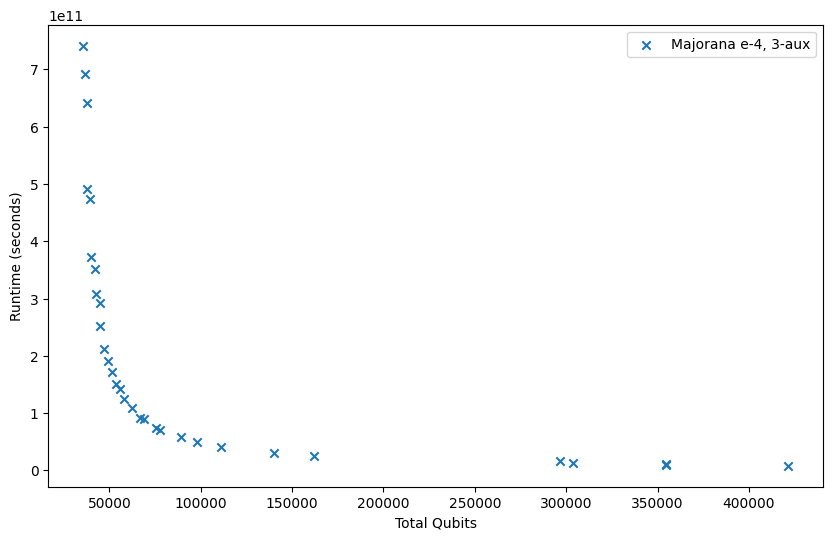

In [53]:
# Displaying estimates for 20x20 lattice size.

import pandas as pd
import matplotlib.pyplot as plt

combined = pd.concat([results.as_frame()])
plt.figure(figsize=(10, 6))
for name, group in combined.groupby("name"):
    plt.scatter(group["qubits"], group["runtime"], marker='x', label=name)
plt.xlabel("Total Qubits")
plt.ylabel("Runtime (seconds)")
plt.legend()
plt.show()

## Next steps

Feel free to use this notebook as a starting point for your own experiments.  For
example, you can

* explore how the results change considering other problem instances of the Heisenberg model
* explore space- and time-trade-offs by changing the value for
  `logical_depth_factor` or `max_t_factories`
* visualize these trade-offs with the space and time diagrams
* use other or customized qubit parameters